**© 2026 Mindverse Computing LLC.**  
Licensed under CC BY-NC 4.0.  
See LICENSE file for patent and commercial restrictions.

# FNet-Style Phasor Transformer

This notebook establishes a **Variational Phasor Transformer** to analyze an oscillatory time-series sequence.

Instead of traditional attention ($Q K^T V$), this model implements the mathematically equivalent **FNet** Transformer Block. 
The Discrete Fourier Transform (`DFT` gate) natively mixes sequence tokens in the frequency domain without free parameters, while flanking Variational Phase Shifts ($S(w_i)$) act as the position-wise Feed-Forward networks.


In [ ]:
# (c) 2026 Mindverse Computing LLC.
# Licensed under CC BY-NC 4.0.
# See LICENSE file for patent and commercial restrictions.

import sys
import os
sys.path.append(os.path.abspath('..'))

import phasorflow as pf
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
torch.manual_seed(42)

## 1. Synthetic Oscillatory Sequence Generation
We synthesize a complex waveform (combining multiple sine frequencies and adding some noise).
We will frame the data such that $T=10$ sequence steps are used to predict the value of the next step $T+1$.


In [2]:
time_steps = 200
T = 10 # Sequence Context Window Length

# Generate base oscillation waveform (composite of 3 frequencies)
t_axis = np.linspace(0, 10 * np.pi, time_steps)
signal = np.sin(t_axis) + 0.5 * np.cos(3 * t_axis) + 0.25 * np.sin(7 * t_axis)
# Add slight noise
signal += np.random.normal(0, 0.1, time_steps)

# Frame into (X, y) sequences
X_seq = []
y_seq = []

for i in range(len(signal) - T):
    X_seq.append(signal[i:i+T])
    y_seq.append(signal[i+T])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Linear Encoding to [-pi/2, pi/2] to preserve Autoregressive Sine dynamics!
max_val = np.max(np.abs(signal))
X_seq_norm = (X_seq / max_val) * (np.pi / 2)
y_seq_norm = (y_seq / max_val) * (np.pi / 2)

# Split into Train / Test (80/20) and cast to PyTorch Tensors
split = int(len(X_seq) * 0.8)
X_train = torch.tensor(X_seq_norm[:split], dtype=torch.float32)
y_train = torch.tensor(y_seq_norm[:split], dtype=torch.float32)
X_test = torch.tensor(X_seq_norm[split:], dtype=torch.float32)
y_test = torch.tensor(y_seq_norm[split:], dtype=torch.float32)

print(f"Generated {X_train.shape[0]} Training Sequences and {X_test.shape[0]} Test Sequences of length T={T}")

Generated 152 Training Sequences and 38 Test Sequences of length T=10


## 2. Transformer FNet Architecture
Our Phasor Transformer will encode the $T=10$ historical steps natively as Phase angles, mix them globally across "time" via the DFT, and apply learnable scalar projections.
The Phase angle of the 0th Thread will be extracted directly as the linear continuous sequence prediction.


In [3]:
def create_phasor_transformer(x_seq, weights):
    # Weights array length: 5*T (Block 1, Block 2, Readout)
    pc = pf.PhasorCircuit(T, name="Phasor_Transformer")
    
    # Data Encoding (Tokens)
    for i in range(T):
        pc.shift(i, x_seq[i])
        
    # --- FNet Transformer Block 1 ---
    # Pre-Projection (Feed-Forward Network)
    for i in range(T):
        pc.shift(i, weights[i])
    # Token Mixing (DFT Attention)
    pc.dft()
    # Post-Projection (Feed-Forward Network)
    for i in range(T):
        pc.shift(i, weights[i + T])
    
    # --- FNet Transformer Block 2 (Deepening) ---
    # Pre-Projection
    for i in range(T):
        pc.shift(i, weights[i + 2*T])
    # Token Mixing
    pc.dft()
    # Post-Projection
    for i in range(T):
        pc.shift(i, weights[i + 3*T])

    # --- Sequence Readout ---
    for i in range(T):
        pc.shift(i, weights[i + 4*T])
        
    return pc

backend = pf.Simulator.get_backend('analytic_simulator')

def vpc_predict_step(x_seq, weights):
    pc = create_phasor_transformer(x_seq, weights)
    res = backend.run(pc)
    
    # Extract continuous phase prediction directly
    prediction = res['phases'][0]
    return prediction

# Initial weights tracked by PyTorch Autograd
initial_weights = torch.empty(5 * T).uniform_(-np.pi/10, np.pi/10).requires_grad_()
print("Untrained Prediction:", vpc_predict_step(X_train[0], initial_weights).item())

Untrained Prediction: 1.2405492067337036


## 3. Training Loop (Mean Squared Error)
We optimize our sequence-predicting network parameters utilizing the powerful continuous optimization algorithm **L-BFGS-B**, minimizing Mean Squared Error (MSE).


In [4]:
def mse_loss(weights):
    predictions = torch.stack([vpc_predict_step(x, weights) for x in X_train])
    loss = torch.mean((predictions - y_train)**2)
    return loss

initial_loss = mse_loss(initial_weights)
print(f"Initial Starting Loss: {initial_loss.item():.4f}")

print("Starting Adam Sequence Optimization...")
optimizer = optim.Adam([initial_weights], lr=0.05)
EPOCHS = 100
loss_history = []

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    loss = mse_loss(initial_weights)
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

optimal_weights = initial_weights.detach()
print(f"\nFinal Optimized Loss: {loss.item():.4f}")

Initial Starting Loss: 1.6912
Starting Adam Sequence Optimization...
Epoch   0 | Loss: 1.6912
Epoch  10 | Loss: 0.1624
Epoch  20 | Loss: 0.1567
Epoch  30 | Loss: 0.1376
Epoch  40 | Loss: 0.0982
Epoch  50 | Loss: 0.0764
Epoch  60 | Loss: 0.0679
Epoch  70 | Loss: 0.0615
Epoch  80 | Loss: 0.0585
Epoch  90 | Loss: 0.0569

Final Optimized Loss: 0.0563


## 4. Evaluation and Prediction Visualization
Let's see how well our deeply-layered Phasor Transformer predicts the Unseen Test set purely from learning overlapping Unit-Circle frequency interference!


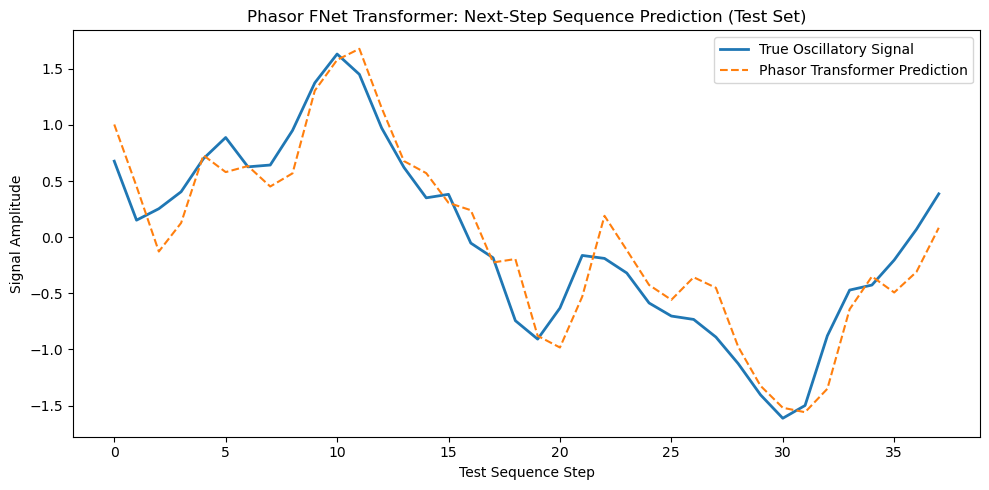

Test Set Prediction MSE: 0.0705
VPC successfully learned sequence correlations across the FNet Block!


In [5]:
# Generate Predictions on Test Set
with torch.no_grad():
    test_predictions_norm = torch.stack([vpc_predict_step(x, optimal_weights) for x in X_test])

# De-normalize outputs back to raw signal domain
test_predictions_true = (test_predictions_norm * max_val / (np.pi / 2)).numpy()
y_test_true = (y_test * max_val / (np.pi / 2)).numpy()

# Plot Results
plt.figure(figsize=(10, 5))
plt.plot(y_test_true, label="True Oscillatory Signal", color='tab:blue', linewidth=2)
plt.plot(test_predictions_true, label="Phasor Transformer Prediction", color='tab:orange', linestyle='--')
plt.title("Phasor FNet Transformer: Next-Step Sequence Prediction (Test Set)")
plt.xlabel("Test Sequence Step")
plt.ylabel("Signal Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

final_mse = np.mean((test_predictions_true - y_test_true)**2)
print(f"Test Set Prediction MSE: {final_mse:.4f}")

if final_mse < 0.2:
    print("VPC successfully learned sequence correlations across the FNet Block!")
else:
    print("Failed to sufficiently resolve sequence dynamics.")

## 5. Manuscript-Grade Multi-Panel Visualizations
This section creates publication-quality multi-panel figures and writes them into the manuscript figure directory.

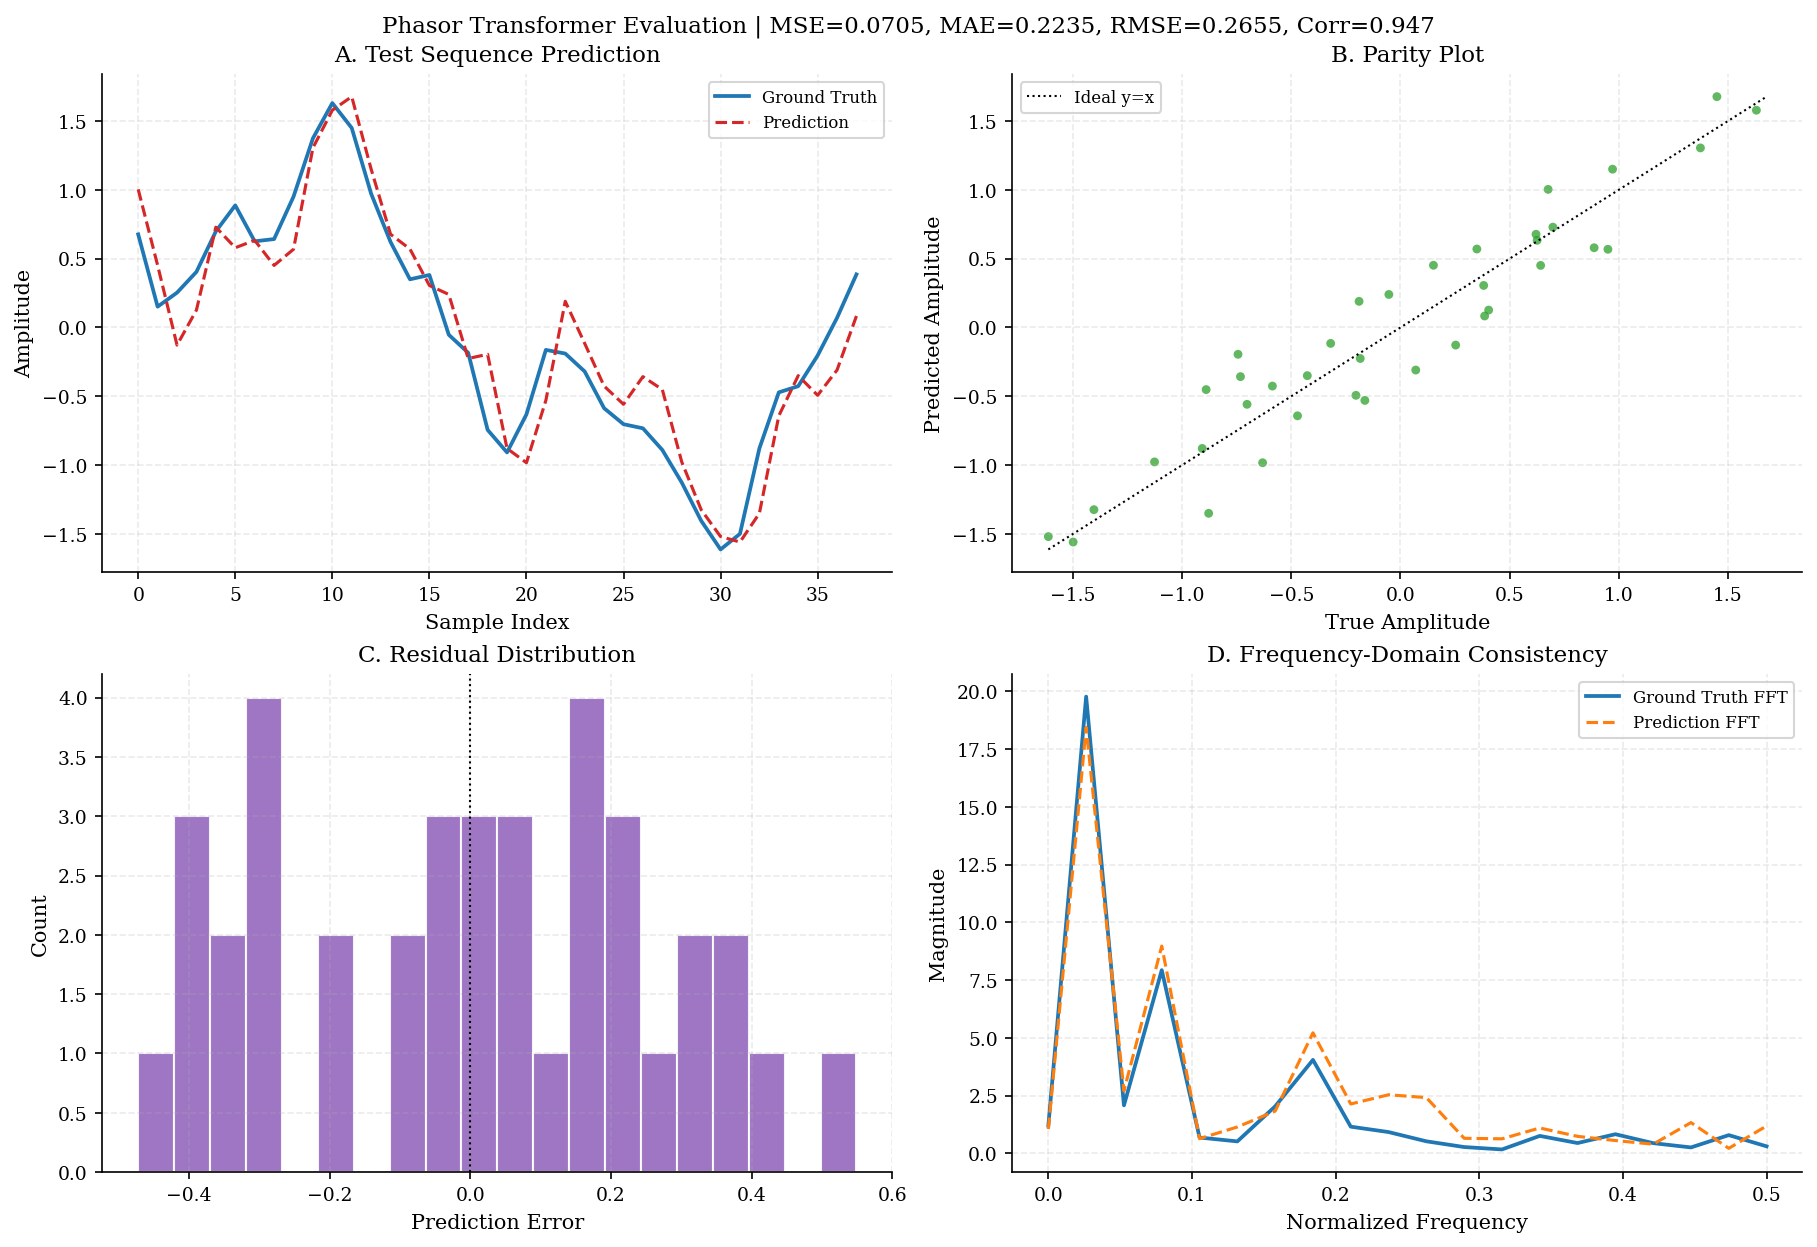

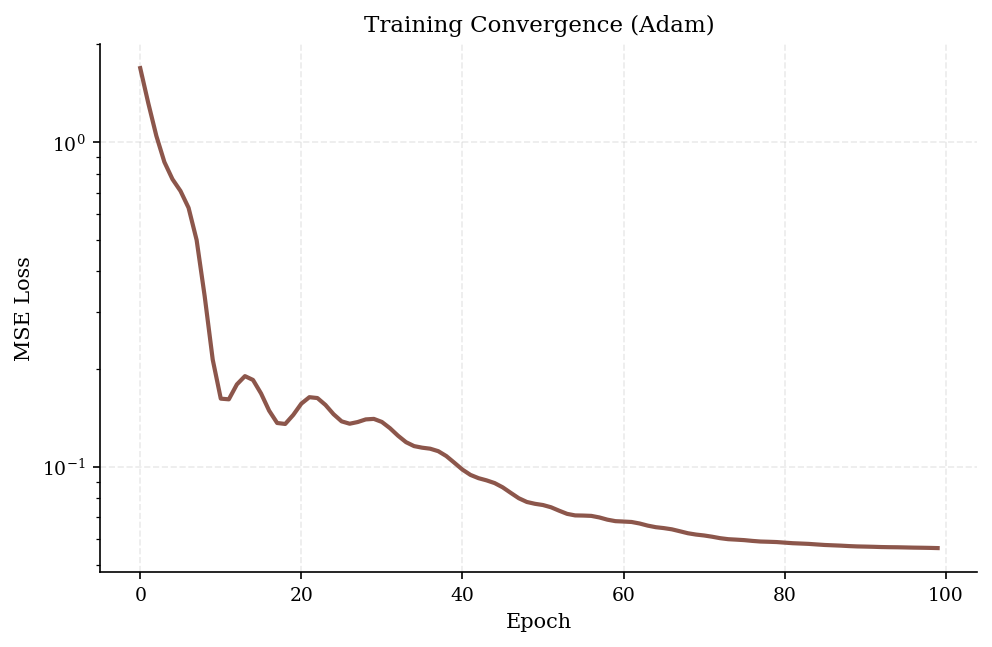

Saved multi-panel figure to: /Users/vasu/Documents/COMPUTE/C-Synchronome/C-PhasorFlow/manuscript/PhasorFlow/figures/phasor_transformer_multi_panel.png
Saved vector figure to: /Users/vasu/Documents/COMPUTE/C-Synchronome/C-PhasorFlow/manuscript/PhasorFlow/figures/phasor_transformer_multi_panel.pdf
Saved convergence figure to: /Users/vasu/Documents/COMPUTE/C-Synchronome/C-PhasorFlow/manuscript/PhasorFlow/figures/phasor_transformer_convergence.png
Saved vector convergence figure to: /Users/vasu/Documents/COMPUTE/C-Synchronome/C-PhasorFlow/manuscript/PhasorFlow/figures/phasor_transformer_convergence.pdf


In [6]:
from pathlib import Path

# Create a manuscript-facing figure output folder relative to notebook location.
repo_root = Path.cwd().resolve().parents[1]
figure_dir = repo_root / "manuscript" / "PhasorFlow" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Publication-style defaults.
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# Metrics and analysis arrays.
residuals = test_predictions_true - y_test_true
mae = np.mean(np.abs(residuals))
rmse = np.sqrt(np.mean(residuals**2))
corr = np.corrcoef(y_test_true, test_predictions_true)[0, 1]

# Frequency-domain comparison (magnitude spectra).
fft_true = np.abs(np.fft.rfft(y_test_true))
fft_pred = np.abs(np.fft.rfft(test_predictions_true))
freq = np.fft.rfftfreq(len(y_test_true), d=1.0)

# Multi-panel manuscript figure.
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# Panel A: Time-domain forecast.
axes[0, 0].plot(y_test_true, color="#1f77b4", linewidth=1.8, label="Ground Truth")
axes[0, 0].plot(test_predictions_true, color="#d62728", linewidth=1.5, linestyle="--", label="Prediction")
axes[0, 0].set_title("A. Test Sequence Prediction")
axes[0, 0].set_xlabel("Sample Index")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].legend(loc="upper right")

# Panel B: Predicted vs true parity.
axes[0, 1].scatter(y_test_true, test_predictions_true, s=18, alpha=0.75, color="#2ca02c", edgecolor="none")
lims = [min(y_test_true.min(), test_predictions_true.min()), max(y_test_true.max(), test_predictions_true.max())]
axes[0, 1].plot(lims, lims, color="black", linewidth=1.0, linestyle=":", label="Ideal y=x")
axes[0, 1].set_title("B. Parity Plot")
axes[0, 1].set_xlabel("True Amplitude")
axes[0, 1].set_ylabel("Predicted Amplitude")
axes[0, 1].legend(loc="upper left")

# Panel C: Residual distribution.
axes[1, 0].hist(residuals, bins=20, color="#9467bd", edgecolor="white", alpha=0.9)
axes[1, 0].axvline(0.0, color="black", linewidth=1.0, linestyle=":")
axes[1, 0].set_title("C. Residual Distribution")
axes[1, 0].set_xlabel("Prediction Error")
axes[1, 0].set_ylabel("Count")

# Panel D: Spectrum consistency.
axes[1, 1].plot(freq, fft_true, color="#1f77b4", linewidth=1.8, label="Ground Truth FFT")
axes[1, 1].plot(freq, fft_pred, color="#ff7f0e", linewidth=1.5, linestyle="--", label="Prediction FFT")
axes[1, 1].set_title("D. Frequency-Domain Consistency")
axes[1, 1].set_xlabel("Normalized Frequency")
axes[1, 1].set_ylabel("Magnitude")
axes[1, 1].legend(loc="upper right")

# Add compact shared metrics.
fig.suptitle(
    f"Phasor Transformer Evaluation | MSE={final_mse:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, Corr={corr:.3f}",
    fontsize=11,
    y=1.02
)

multi_panel_png = figure_dir / "phasor_transformer_multi_panel.png"
multi_panel_pdf = figure_dir / "phasor_transformer_multi_panel.pdf"
fig.savefig(multi_panel_png, bbox_inches="tight")
fig.savefig(multi_panel_pdf, bbox_inches="tight")
plt.show()

# Optional: convergence figure if training loss history is available.
if "loss_history" in globals() and len(loss_history) > 0:
    fig2, ax2 = plt.subplots(figsize=(6.5, 4.2), constrained_layout=True)
    ax2.plot(loss_history, color="#8c564b", linewidth=2.0)
    ax2.set_title("Training Convergence (Adam)")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("MSE Loss")
    ax2.set_yscale("log")
    conv_png = figure_dir / "phasor_transformer_convergence.png"
    conv_pdf = figure_dir / "phasor_transformer_convergence.pdf"
    fig2.savefig(conv_png, bbox_inches="tight")
    fig2.savefig(conv_pdf, bbox_inches="tight")
    plt.show()

print(f"Saved multi-panel figure to: {multi_panel_png}")
print(f"Saved vector figure to: {multi_panel_pdf}")
if "loss_history" in globals() and len(loss_history) > 0:
    print(f"Saved convergence figure to: {conv_png}")
    print(f"Saved vector convergence figure to: {conv_pdf}")